In [137]:
import pandas as pd
import os
import re
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import ast

In [2]:
test_df = pd.read_csv("/home/gridsan/tmackey/cdvae/data/mp_20/test.csv")

In [3]:
test_df.head()

,Unnamed: 0.1,Unnamed: 0,material_id,formation_energy_per_atom,band_gap,pretty_formula,e_above_hull,elements,cif,spacegroup.number,xrd,xrd_peak_locations,xrd_peak_intensities,atomic_numbers,TsachID,disc_sim_xrd
0,0,6000,mp-10009,-0.575092,0.898,GaTe,0.000000,"['Ga', 'Te']",# generated using pymatgen\ndata_GaTe\n_symmet...,194,DiffractionPattern\n$2\Theta$: [ 9.600175 19...,"[9.60017500043424, 19.268570825893903, 24.8663...","[17.585724322472384, 61.383057358029205, 59.58...","[31, 31, 31, 31, 52, 52, 52, 52]",GaGaGaGaTeTeTeTe4.13459944.134599418.4255790.0...,[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...
1,1,37702,mp-1218989,-0.942488,0.000,SmThCN,0.044109,"['C', 'N', 'Sm', 'Th']",# generated using pymatgen\ndata_SmThCN\n_symm...,160,DiffractionPattern\n$2\Theta$: [14.73274605 28...,"[14.732746046285516, 28.15844191532359, 29.461...","[7.346709718249399, 4.800663271234867, 100.0, ...","[62, 90, 6, 7]",SmThCN6.38429836.38429836.384298133.849632733....,[ 0. 0. 0. 0. ...
2,2,42245,mp-1225695,0.064863,0.000,CuNi,0.064863,"['Cu', 'Ni']",# generated using pymatgen\ndata_CuNi\n_symmet...,65,DiffractionPattern\n$2\Theta$: [21.46024598 40...,"[21.460245979275125, 40.774899092585635, 43.72...","[0.1386302972376211, 0.0705249941414367, 30.27...","[29, 28]",CuNi2.44746162.44746214.14065390.090.0115.2864378,[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...
3,3,780,mp-1220884,-1.456116,0.000,NaTiVS4,0.000000,"['Na', 'S', 'Ti', 'V']",# generated using pymatgen\ndata_NaTiVS4\n_sym...,8,DiffractionPattern\n$2\Theta$: [12.60702915 15...,"[12.607029147768102, 15.149181551064249, 18.33...","[100.0, 3.2081172418276256, 1.7042497801132475...","[11, 22, 23, 16, 16, 16, 16]",NaTiVSSSS7.29525827.29525825.906234282.2029106...,[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...
4,4,35749,mp-1224266,0.024139,0.000,Ho3TmMn8,0.036496,"['Ho', 'Mn', 'Tm']",# generated using pymatgen\ndata_Ho3TmMn8\n_sy...,8,DiffractionPattern\n$2\Theta$: [10.56971432 19...,"[10.569714321417708, 19.46016116903007, 20.300...","[0.03841376720098142, 20.386062951020786, 12.8...","[67, 67, 67, 69, 25, 25, 25, 25, 25, 25, 25, 25]",HoHoHoTmMnMnMnMnMnMnMnMn5.13506275.3455338.389...,[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...


In [5]:
!ls /home/gridsan/tmackey/cdvae/data/mp_20/

README.md  test_reserve.csv  train.csv		train_xrd.csv  val_reserve.csv
test.csv   test_xrd.csv      train_reserve.csv	val.csv        val_xrd.csv


In [6]:
from typing import Any, Dict

import hydra
import numpy as np
import omegaconf
import torch
import pytorch_lightning as pl
import torch.nn as nn
from torch.nn import functional as F
from torch_scatter import scatter
from tqdm import tqdm

In [7]:
# Make sure to provide the correct path to the .pt file
model_path = '/home/gridsan/tmackey/hydra/singlerun/2023-11-08/dropout_input_layer_mp_20/eval_recon.pt'

# Load the model
model = torch.load(model_path)

# If the model includes not only the state_dict but also the architecture
# You might need to define the model architecture before loading the state_dict
# model = TheModelClass(*args, **kwargs)
# model.load_state_dict(torch.load(model_path))

AttributeError: 'dict' object has no attribute 'eval'

In [9]:
data = model

In [14]:
data['num_atoms']

tensor([[ 8,  4,  2,  7, 12, 16, 20,  5, 13,  8,  4,  5, 15, 12,  4, 10, 12,  6,
         16,  6, 12, 14, 13,  9, 12,  4,  7, 20, 18, 20,  5,  8,  6, 14, 10, 20,
         10, 16,  5, 14,  8, 10, 16,  4, 10, 12,  4, 16, 18,  4,  6, 20,  4, 14,
         18,  8, 10, 17,  8,  7, 12, 16,  8,  8, 18,  8,  4,  9, 16, 10,  8, 20,
         10, 20,  7,  4, 20,  3,  3, 20,  4, 12,  8,  4,  8,  7, 16,  6,  6,  7,
         20, 10, 20, 20,  5,  6,  6,  4, 10, 13, 10,  8,  6,  9, 18,  7,  4, 10,
         12,  6,  4,  2, 13,  4,  3, 20,  6, 18,  4,  7, 10, 10,  4,  6, 12,  4,
          8,  8,  2,  4, 11, 10,  5, 14, 18,  6,  8,  7, 16, 14, 10,  8, 18,  4,
         13, 16,  8,  4,  5, 10, 19, 16,  9, 19,  8, 20, 10, 14,  8, 10, 20, 10,
          5, 18, 10,  6, 12,  8, 20, 12, 10, 10, 10,  8, 20, 16, 18,  6, 20,  4,
          8,  8, 10,  6,  6,  8, 12, 18, 18, 14, 10,  6, 16,  4, 19, 14,  7,  9,
         16,  3,  6, 10, 10,  8,  8,  4, 18, 18,  4, 12, 14,  4,  6,  8,  4,  6,
         10, 12, 10, 10,  8,

In [31]:
# Path to the directory containing the CIF files
cif_directory =  '/home/gridsan/tmackey/hydra/singlerun/2023-11-08/dropout_input_layer_mp_20'

# Read the CIF files and extract the formulas after 'ndata_'
cif_formulas = {}
for filename in os.listdir(cif_directory):
    if filename.endswith('.cif'):
        if filename.startswith('gt'):
            with open(os.path.join(cif_directory, filename), 'r') as file:
                content = file.read()
                # Search for the pattern after 'ndata_'
                match = re.search(r'data_([A-Za-z0-9_]*)', content)
                if match:
                    # Extract the formula
                    formula = match.group(1)
                    cif_formulas[filename] = formula


In [20]:
cif_contents

{'gt_Th2_Si2_Ru4_C2.cif': "# generated using pymatgen\ndata_ThSiRu2C\n_symmetry_space_group_name_H-M   'P 1'\n_cell_length_a   3.95256591\n_cell_length_b   5.96237230\n_cell_length_c   7.20665979\n_cell_angle_alpha   90.00000000\n_cell_angle_beta   90.00000000\n_cell_angle_gamma   109.35736847\n_symmetry_Int_Tables_number   1\n_chemical_formula_structural   ThSiRu2C\n_chemical_formula_sum   'Th2 Si2 Ru4 C2'\n_cell_volume   160.23600836\n_cell_formula_units_Z   2\nloop_\n _symmetry_equiv_pos_site_id\n _symmetry_equiv_pos_as_xyz\n  1  'x, y, z'\nloop_\n _atom_site_type_symbol\n _atom_site_label\n _atom_site_symmetry_multiplicity\n _atom_site_fract_x\n _atom_site_fract_y\n _atom_site_fract_z\n _atom_site_occupancy\n  Th  Th0  1  0.44646400  0.89292800  0.75000000  1\n  Th  Th1  1  0.55353600  0.10707200  0.25000000  1\n  Si  Si2  1  0.72771001  0.45541999  0.75000000  1\n  Si  Si3  1  0.27228999  0.54457998  0.25000000  1\n  Ru  Ru4  1  0.16464999  0.32929999  0.94377500  1\n  Ru  Ru5  1 

In [141]:
# Assuming 'df' is your DataFrame and it has a column 'cif_content'
# Select the first 256 rows of the DataFrame
df_subset = test_df.iloc[:256].copy()

# Add a new column for the comparison result in the subset
df_subset['correctly_classified'] = False

# Function to find a matching CIF file
def find_matching_cif_file(cif_text, cif_contents):
    for filename, content in cif_formulas.items():
        if content in cif_text:  # Stripping to avoid whitespace issues
            return True
    return False

# Apply the function to each row in the subset DataFrame
for index, row in df_subset.iterrows():
    df_subset.at[index, 'correctly_classified'] = find_matching_cif_file(row['cif'], cif_contents)

# Now 'df_subset' will have a new column 'matching_cif_file' with the name of the matching CIF file or None
print(df_subset[['cif', 'correctly_classified']])

                                                   cif  correctly_classified
0    # generated using pymatgen\ndata_GaTe\n_symmet...                 False
1    # generated using pymatgen\ndata_SmThCN\n_symm...                  True
2    # generated using pymatgen\ndata_CuNi\n_symmet...                 False
3    # generated using pymatgen\ndata_NaTiVS4\n_sym...                 False
4    # generated using pymatgen\ndata_Ho3TmMn8\n_sy...                  True
..                                                 ...                   ...
251  # generated using pymatgen\ndata_ThCrS3\n_symm...                  True
252  # generated using pymatgen\ndata_CePRuO\n_symm...                 False
253  # generated using pymatgen\ndata_MoPO5\n_symme...                 False
254  # generated using pymatgen\ndata_SrO2\n_symmet...                 False
255  # generated using pymatgen\ndata_Ba2DyInSe5\n_...                 False

[256 rows x 2 columns]


In [38]:
np.mean(df_subset['correctly_classified'])

0.53515625

In [42]:
df_misclassfified = df_subset[df_subset['correctly_classified']==False]

In [44]:
len(df_misclassfified)

119

Specifically, I am interested in these general questions 
* What are the properties (chemical composition - how many elements, what elements, etc.; lattice parameters, etc.) of the ground truth misclassified / correctly classified compounds? 
* What are the properties (chemical composition - how many elements, what elements, etc.; lattice parameters, etc.) of the predicted misclassified / correctly classified compounds? 
* What properties of the predicted compounds are farthest from ground truth?  <- maybe work 
* How do changes in diffusion parameters affect these? <- maybe work on this later 


In [66]:
list_of_misclassified_compounds = list(df_misclassfified['pretty_formula'])

In [67]:
list_of_misclassified_compounds

['GaTe',
 'CuNi',
 'NaTiVS4',
 'LiMnO2',
 'Fe(HO)2',
 'AlAu4',
 'K2Hg3(GeS4)2',
 'Zr2VRe3',
 'Hf2AlSi',
 'Fe3Te2Se',
 'Ti3N2O3',
 'SbNO',
 'TmNiAs',
 'P2O5',
 'Ta3AlFe8',
 'GaCuGeSe4',
 'LaPr3(GaO3)4',
 'Eu2MnRhO6',
 'Ce(InPt)2',
 'LaTm(Ge2Ir)2',
 'CrAgSn(SeS)2',
 'EuAl2Ge',
 'AcPm3',
 'BeH2',
 'Pm2RuRh',
 'TbCrSe3',
 'Li2Cu4S3',
 'Ba3(H6Ir)2',
 'ThMn2',
 'Fe9B4Ir3',
 'HoZnSn2',
 'TiRe2Mo',
 'NiAgO2',
 'BaTbEuSbO6',
 'Cs2KCrCl6',
 'NaTi3Nb(CuO4)3',
 'KBi(PSe3)2',
 'BaSn2',
 'EuGa3(BO3)4',
 'ZnPd5Se',
 'ZnCu2SnS4',
 'ZnSb2',
 'Li5SbS',
 'Cu2O3',
 'K3RhF6',
 'Hf2Se3',
 'K5(TmI4)3',
 'Li(TiS2)3',
 'K2Zr(PO4)2',
 'Cs2KPdF6',
 'Rb2SnHgTe4',
 'Te2W3(SeS)2',
 'BiIrS',
 'Nb4AgS8',
 'UCo4Sn',
 'LaGa2Co3',
 'YbGaCu4',
 'Eu3Al2O7',
 'BaP3',
 'P4Ru',
 'Si(CN2)2',
 'La3Ge5',
 'K2TlAgBr6',
 'Tb12Co5Bi',
 'TmCuS2',
 'BaZnSO',
 'Eu(SiRh)2',
 'Ti2Ga3',
 'Y5(MoO6)2',
 'Li2MnCoO4',
 'K(SiPd)4',
 'Gd2Cu(GeO3)4',
 'Cs3LiCl4',
 'MnPbO3',
 'Li2VF4',
 'FeCoB2',
 'Tb2Co2I',
 'MnO2',
 'Ti2S3',
 'BaSrEuWO6',
 'C

In [68]:
df_correctly_classified = df_subset[df_subset['correctly_classified']==True]

In [69]:
list_of_corr_classified_compounds = list(df_correctly_classified['pretty_formula'])

In [70]:
list_of_corr_classified_compounds

['SmThCN',
 'Ho3TmMn8',
 'Sm(Fe5Mo)2',
 'SmHo3Ni4',
 'ScAlRh2',
 'Sm(CoB)2',
 'Eu2CrSbO6',
 'MgCd5',
 'Mg(CoGe)6',
 'Cs2CeCl6',
 'Yb2InHg',
 'Sm(BOs)4',
 'Mg(AlSi)2',
 'Y3Lu',
 'Mo2As3P',
 'Ca3VN3',
 'Rb2NaCrCl6',
 'Rb2CeCuBr6',
 'CsYbBr3',
 'TbSm3',
 'ThSiRu2C',
 'TaBeRu2',
 'Ca(GaP)2',
 'ErZnRh',
 'Sr2FeCuSO3',
 'LaCuPb',
 'Ag3Pd',
 'Sm(HO)3',
 'HfZr3',
 'Pr2InCu2',
 'Ce3Ga',
 'CdPb2(ClO)2',
 'MnCuF6',
 'K2NaAs',
 'CdTeMoO6',
 'ErMgTl',
 'K2NaYCl6',
 'YbGe3',
 'In2AgSe4',
 'Sm3Ho',
 'HfSeS',
 'EuHg2Bi',
 'ZrFeSi',
 'CsReF6',
 'SmDyZn2',
 'InGa(AgTe2)2',
 'ZrTi3As2',
 'K2PtC2',
 'Nd2PdRu3',
 'NdAlCo4',
 'K3Cd',
 'AlNi2',
 'NdGa2Co3',
 'Sr2Cu(OF)2',
 'CaYbPb2',
 'CaEuNbFeO6',
 'PuPt5',
 'ThScTc2',
 'LuIn',
 'YbNbRu2',
 'HoCuGe',
 'CaNiO3',
 'Sc2AlZn',
 'K4ZnAs2',
 'KInBr3',
 'Eu2HfZrO6',
 'CuSnPd2',
 'Tb3Y',
 'IrO3',
 'LiMg',
 'LiHfSe2',
 'Er3(FeGe)4',
 'U2PN2',
 'Li2GeF6',
 'EuGaAg',
 'GeMo3',
 'Cd(GaSe2)2',
 'Mg2TcO4',
 'BaCd3',
 'CeCdAu2',
 'Ti4FeSe8',
 'Tb2ZnIr',
 'K2LiInF6',
 'BaR

Interesting, the model doesn't seem to be doing much worse on ternaries, but there does seem to be a slightly higher miclassification of molecular crystals.  

In [71]:
just_the_molecular_misclassified = [x for x in list_of_misclassified_compounds if '(' in x]

In [72]:
len(just_the_molecular_misclassified)

25

In [75]:
just_the_molecular_corr_classified = [x for x in list_of_corr_classified_compounds if '(' in x]

In [76]:
len(just_the_molecular_corr_classified)

15

In [83]:
# Regular expression to match element symbols
# Assumes elements start with a capital letter followed by zero or one lowercase letters
element_regex = r'[A-Z][a-z]?'

# Initialize a Counter to keep track of element occurrences
element_counter = Counter()

# Iterate over each chemical formula
for formula in list_of_corr_classified_compounds:
    # Find all element symbols in the formula
    elements = re.findall(element_regex, formula)
    # Update the counter with the elements found
    element_counter.update(elements)

# Convert the Counter object to a dictionary
corr_element_dict = dict(element_counter)

# Sort the dictionary by value and create a sorted dictionary
sorted_element_dict = dict(sorted(corr_element_dict.items(), key=lambda item: item[1], reverse=True))

print(sorted_element_dict)

{'O': 17, 'Cu': 14, 'Mg': 12, 'Sm': 11, 'Ge': 11, 'In': 11, 'Cd': 10, 'S': 10, 'Ca': 9, 'Ga': 9, 'Fe': 8, 'Ni': 8, 'Al': 8, 'Hg': 8, 'K': 8, 'Co': 7, 'Yb': 7, 'Y': 7, 'Pd': 7, 'Se': 7, 'Li': 7, 'Sc': 6, 'Eu': 6, 'Ce': 6, 'Na': 6, 'Ru': 6, 'Hf': 6, 'F': 6, 'Nd': 6, 'Ho': 5, 'Mn': 5, 'Cr': 5, 'Lu': 5, 'As': 5, 'P': 5, 'Br': 5, 'Tb': 5, 'Zn': 5, 'Ag': 5, 'Zr': 5, 'Tl': 5, 'Th': 4, 'N': 4, 'Mo': 4, 'Rh': 4, 'Sb': 4, 'Cl': 4, 'Si': 4, 'Pt': 4, 'Ir': 4, 'Au': 4, 'C': 3, 'Cs': 3, 'Rb': 3, 'Er': 3, 'Sr': 3, 'Pb': 3, 'Bi': 3, 'Dy': 3, 'Nb': 3, 'Sn': 3, 'U': 3, 'Gd': 3, 'Tm': 2, 'B': 2, 'V': 2, 'La': 2, 'H': 2, 'Te': 2, 'Re': 2, 'Ti': 2, 'Tc': 2, 'Ba': 2, 'Os': 1, 'Ta': 1, 'Be': 1, 'Pr': 1, 'Pu': 1}


In [85]:
# Regular expression to match element symbols
# Assumes elements start with a capital letter followed by zero or one lowercase letters
element_regex = r'[A-Z][a-z]?'

# Initialize a Counter to keep track of element occurrences
element_counter = Counter()

# Iterate over each chemical formula
for formula in list_of_misclassified_compounds:
    # Find all element symbols in the formula
    elements = re.findall(element_regex, formula)
    # Update the counter with the elements found
    element_counter.update(elements)

# Convert the Counter object to a dictionary
incorr_element_dict = dict(element_counter)

# Sort the dictionary by value and create a sorted dictionary
sorted_element_dict = dict(sorted(incorr_element_dict.items(), key=lambda item: item[1], reverse=True))

print(sorted_element_dict)

{'O': 37, 'S': 14, 'Cu': 12, 'Mn': 12, 'Se': 11, 'Ti': 10, 'Li': 10, 'K': 10, 'Si': 10, 'Ba': 10, 'Co': 10, 'Ga': 9, 'Eu': 9, 'Sn': 9, 'Fe': 8, 'Al': 7, 'Ge': 7, 'P': 7, 'F': 7, 'Zn': 6, 'Pd': 6, 'Te': 5, 'La': 5, 'Ir': 5, 'Cr': 5, 'Cs': 5, 'Ni': 4, 'V': 4, 'H': 4, 'Au': 4, 'N': 4, 'Sb': 4, 'Tm': 4, 'Rh': 4, 'Ag': 4, 'Ru': 4, 'Tb': 4, 'B': 4, 'Sr': 4, 'Na': 3, 'Re': 3, 'Ce': 3, 'Pt': 3, 'Mo': 3, 'Cl': 3, 'Nb': 3, 'Bi': 3, 'I': 3, 'W': 3, 'C': 3, 'Br': 3, 'Y': 3, 'Pb': 3, 'Hg': 2, 'Zr': 2, 'Hf': 2, 'In': 2, 'Pm': 2, 'Th': 2, 'Ho': 2, 'Rb': 2, 'U': 2, 'Tl': 2, 'Gd': 2, 'Dy': 2, 'As': 1, 'Ta': 1, 'Pr': 1, 'Ac': 1, 'Be': 1, 'Yb': 1, 'Lu': 1}


In [88]:
# New dictionary to store the results
result_element_dict = {}

# Iterate over the incorrect element dictionary
for element, count in incorr_element_dict.items():
    # Subtract the count from the correct element dictionary if the element is present
    if element in corr_element_dict:
        result_element_dict[element] = count - corr_element_dict.get(element, 0)
    else:
        # Otherwise, just copy the count from the incorrect element dictionary
        result_element_dict[element] = count

# Sort the dictionary by value and create a sorted dictionary
sorted_element_dict = dict(sorted(result_element_dict.items(), key=lambda item: item[1], reverse=True))

print(sorted_element_dict)

{'O': 20, 'Ti': 8, 'Ba': 8, 'Mn': 7, 'Si': 6, 'Sn': 6, 'S': 4, 'Se': 4, 'Te': 3, 'Li': 3, 'La': 3, 'Eu': 3, 'I': 3, 'W': 3, 'Co': 3, 'V': 2, 'H': 2, 'K': 2, 'Tm': 2, 'P': 2, 'Pm': 2, 'B': 2, 'Cs': 2, 'Re': 1, 'Ir': 1, 'Ac': 1, 'Zn': 1, 'F': 1, 'Sr': 1, 'Ga': 0, 'Fe': 0, 'Au': 0, 'N': 0, 'Sb': 0, 'Ta': 0, 'Pr': 0, 'Rh': 0, 'Cr': 0, 'Be': 0, 'Nb': 0, 'Bi': 0, 'C': 0, 'Pb': 0, 'Al': -1, 'Pt': -1, 'Ag': -1, 'Tb': -1, 'Mo': -1, 'Cl': -1, 'Pd': -1, 'Rb': -1, 'U': -1, 'Gd': -1, 'Dy': -1, 'Cu': -2, 'Ru': -2, 'Th': -2, 'Br': -2, 'Na': -3, 'Zr': -3, 'Ce': -3, 'Ho': -3, 'Tl': -3, 'Ni': -4, 'Ge': -4, 'Hf': -4, 'As': -4, 'Y': -4, 'Lu': -4, 'Hg': -6, 'Yb': -6, 'In': -9}


Ok, so a good first step for limiting or model might be to eliminate oxides, non-metals and/or alkali / alkaline earth metals 

Another reasonable guess as to what kinds of compounds might be more misclassified are compounds with a lot of atoms 

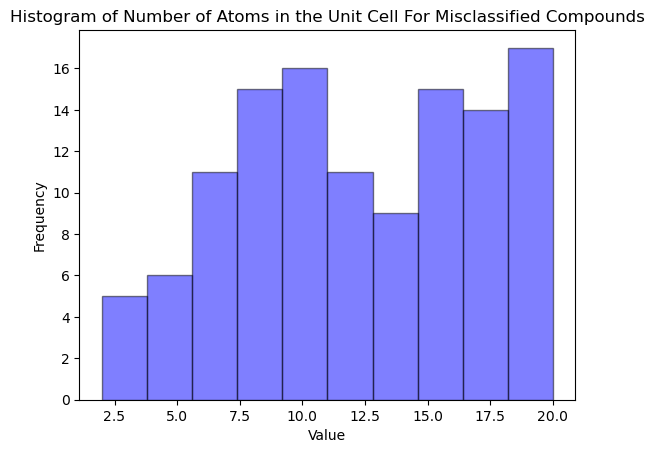

In [125]:
#first, let's get the number of elements in each of the crystals
num_elements = [len(ast.literal_eval(alist)) for alist in df_misclassfified['atomic_numbers']]

# Create a histogram
plt.hist(num_elements, bins=10, alpha=0.5, color='blue', edgecolor='black')

# Add titles and labels
plt.title('Histogram of Number of Atoms in the Unit Cell For Misclassified Compounds')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Show the plot
plt.show()


In [127]:
np.mean(num_elements)

12.394957983193278

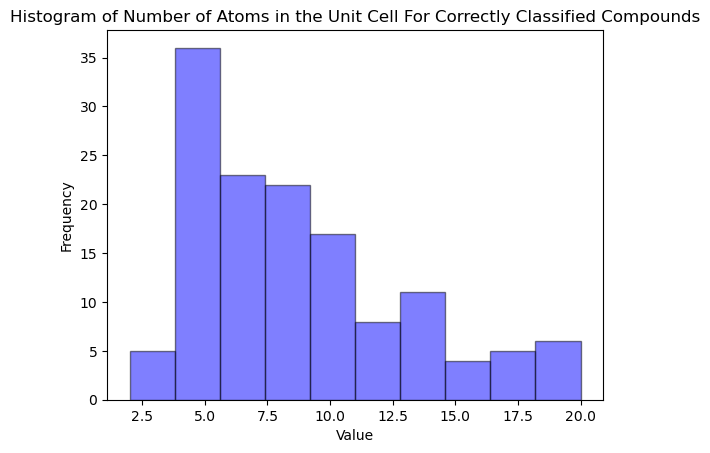

In [128]:
#first, let's get the number of elements in each of the crystals
num_elements = [len(ast.literal_eval(alist)) for alist in df_correctly_classified['atomic_numbers']]

# Create a histogram
plt.hist(num_elements, bins=10, alpha=0.5, color='blue', edgecolor='black')

# Add titles and labels
plt.title('Histogram of Number of Atoms in the Unit Cell For Correctly Classified Compounds')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Show the plot
plt.show()


In [129]:
np.mean(num_elements)

8.583941605839415

Looks like the chance of getting a correct prediction drops off pretty steeply when the unit cell gets too big (though we're only limiting ourselves to 20 atom large unit cells here). I guess we could limit ourselves to compounds smaller than 10? Idk this seeems less valid than what we're doing on the alkaline earths. 

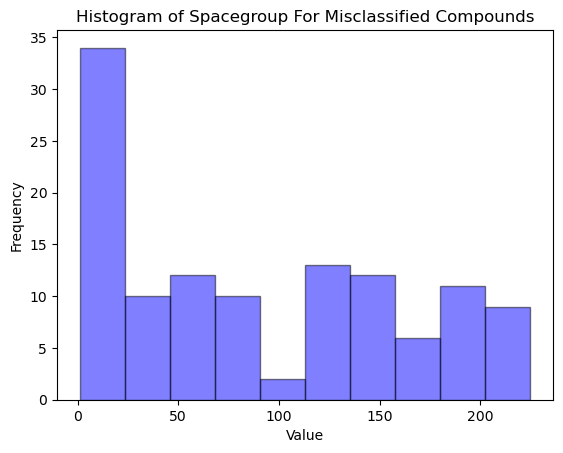

In [135]:
#first, let's get the number of elements in each of the crystals
space_groups = [float(number) for number in df_misclassfified['spacegroup.number']]

# Create a histogram
plt.hist(space_groups, bins=10, alpha=0.5, color='blue', edgecolor='black')

# Add titles and labels
plt.title('Histogram of Spacegroup For Misclassified Compounds')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Show the plot
plt.show()


In [136]:
np.mean(space_groups)

91.0

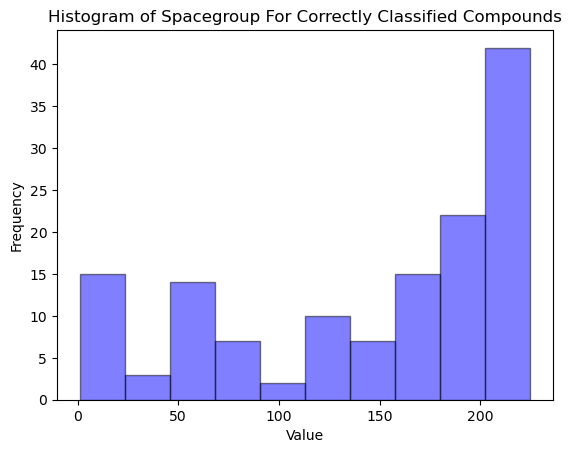

In [133]:
#first, let's get the number of elements in each of the crystals
space_groups = [float(number) for number in df_correctly_classified['spacegroup.number']]

# Create a histogram
plt.hist(space_groups, bins=10, alpha=0.5, color='blue', edgecolor='black')

# Add titles and labels
plt.title('Histogram of Spacegroup For Correctly Classified Compounds')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Show the plot
plt.show()


In [134]:
np.mean(space_groups)

147.26277372262774

The space group results are awesomely interpretable! The model does better on more symmetric crystals and worse on less symmetric ones. This makes sense! 

Unfortunately, we can't just kick out the less symmetric crystals, that would be kind of ridiculous. But this was a very satisfying result

Ok, so main takeaways in terms of whether we can be more restrictive in terms of the crystals we're using is that we should probably impose some filters on atomic composition, at least for now. This is fairly straightforward in terms of restricting the test data, but requires a bit more thought in regards to applying to the training data since it will reduce the amount of training data availible, potentially by a lot. This is potentially addressable by just finding more data though. 

In addition, we need to start thinking more carefully about our train-val-test sets, especially if we start manipulating constraints and filters based on results. These initial results were done off the test set, but we may need to come back and redo on the val set to preserve the integrety of the test. In fact, we may need to re-split or get some more data for a fresh test set to avoid any kind of accidental overfitting to the test data.

Now, let's figure out why each one got misclassified to figure out how we can do better! The first way a crystal structure could fail is if it's just invalid. So let's see what percentage of the generated crystal structures were invalid. 

In [139]:
#added by Tsach
from eval_utils import (
    smact_validity, structure_validity, CompScaler, get_fp_pdist,
    load_config, load_data, get_crystals_list, prop_model_eval, compute_cov)

from collections import Counter
import argparse
import os
import json

import numpy as np
from pathlib import Path
from tqdm import tqdm
from p_tqdm import p_map
from scipy.stats import wasserstein_distance

from pymatgen.core.structure import Structure
from pymatgen.core.composition import Composition
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.structure_matcher import StructureMatcher
from matminer.featurizers.site.fingerprint import CrystalNNFingerprint
from matminer.featurizers.composition.composite import ElementProperty

CrystalNNFP = CrystalNNFingerprint.from_preset("ops")
CompFP = ElementProperty.from_preset('magpie')

Percentiles = {
    'mp20': np.array([-3.17562208, -2.82196882, -2.52814761]),
    'carbon': np.array([-154.527093, -154.45865733, -154.44206825]),
    'perovskite': np.array([0.43924842, 0.61202443, 0.7364607]),
}

COV_Cutoffs = {
    'mp20': {'struc': 0.4, 'comp': 10.},
    'carbon': {'struc': 0.2, 'comp': 4.},
    'perovskite': {'struc': 0.2, 'comp': 4},
}

In [144]:
class Crystal(object):
    def __init__(self, crys_array_dict):
        self.frac_coords = crys_array_dict['frac_coords']
        self.atom_types = crys_array_dict['atom_types']
        self.lengths = crys_array_dict['lengths']
        self.angles = crys_array_dict['angles']
        self.dict = crys_array_dict

        self.get_structure()
        self.get_composition()
        self.get_validity()
        self.get_fingerprints()
    def get_structure(self):
        if min(self.lengths.tolist()) < 0:
            self.constructed = False
            self.invalid_reason = 'non_positive_lattice'
        else:
            try:
                self.structure = Structure(
                    lattice=Lattice.from_parameters(
                        *(self.lengths.tolist() + self.angles.tolist())),
                    species=self.atom_types, coords=self.frac_coords, coords_are_cartesian=False)
                self.constructed = True
            except Exception:
                self.constructed = False
                self.invalid_reason = 'construction_raises_exception'
            if self.structure.volume < 0.1:
                self.constructed = False
                self.invalid_reason = 'unrealistically_small_lattice'
    def get_composition(self):
        elem_counter = Counter(self.atom_types)
        composition = [(elem, elem_counter[elem])
                       for elem in sorted(elem_counter.keys())]
        elems, counts = list(zip(*composition))
        counts = np.array(counts)
        counts = counts / np.gcd.reduce(counts)
        self.elems = elems
        self.comps = tuple(counts.astype('int').tolist())
    def get_validity(self):
        self.comp_valid = smact_validity(self.elems, self.comps)
        if self.constructed:
            self.struct_valid = structure_validity(self.structure)
        else:
            self.struct_valid = False
        self.valid = self.comp_valid and self.struct_valid
    def get_fingerprints(self):
        elem_counter = Counter(self.atom_types)
        comp = Composition(elem_counter)
        self.comp_fp = CompFP.featurize(comp)
        try:
            site_fps = [CrystalNNFP.featurize(
                self.structure, i) for i in range(len(self.structure))]
        except Exception:
            # counts crystal as invalid if fingerprint cannot be constructed.
            print('oops')
            self.valid = False
            self.comp_fp = None
            self.struct_fp = None
            return
        self.struct_fp = np.array(site_fps).mean(axis=0)

In [146]:
def get_file_paths(root_path, task, label='', suffix='pt'):
    if label == '':
        out_name = f'eval_{task}.{suffix}'
    else:
        out_name = f'eval_{task}_{label}.{suffix}'
    out_name = os.path.join(root_path, out_name)
    return out_name


In [147]:
def get_crystal_array_list(file_path, batch_idx=0):
    data = load_data(file_path)
    crys_array_list = get_crystals_list(
        data['frac_coords'][batch_idx],
        data['atom_types'][batch_idx],
        data['lengths'][batch_idx],
        data['angles'][batch_idx],
        data['num_atoms'][batch_idx])

    if 'input_data_batch' in data:
        batch = data['input_data_batch']
        if isinstance(batch, dict):
            true_crystal_array_list = get_crystals_list(
                batch['frac_coords'], batch['atom_types'], batch['lengths'],
                batch['angles'], batch['num_atoms'])
        else:
            true_crystal_array_list = get_crystals_list(
                batch.frac_coords, batch.atom_types, batch.lengths,
                batch.angles, batch.num_atoms)
    else:
        true_crystal_array_list = None

    return crys_array_list, true_crystal_array_list

In [198]:
recon_file_path = get_file_paths('/home/gridsan/tmackey/hydra/singlerun/2023-11-08/dropout_input_layer_mp_20/', 'recon',"")

# def get_crystal_array_list(file_path, batch_idx=0):
file_path = recon_file_path

crys_array_list, true_crystal_array_list = get_crystal_array_list(file_path, batch_idx=0)

In [195]:
# Add a new column for the comparison result in the subset
indices = list(df_subset['correctly_classified'] == False)
int_indices = [i for i, x in enumerate(indices) if x]

In [199]:
#we only want the misclassified ones 
crys_array_list = [crys_array_list[indice] for indice in int_indices]

In [201]:
pred_crys = []
counter = 0 
for x in crys_array_list: 
    pred_crys.append(Crystal(x))

In [211]:
pred_crys[2].structure

Structure Summary
Lattice
    abc : 3.285897970199584 6.386678695678712 6.777977466583252
 angles : 112.03535461425781 96.25308227539062 90.2225341796875
 volume : 130.91290482620786
      A : 3.2663484551566206 0.0 -0.35790115962051017
      B : -0.28750502555451174 5.913162653108792 -2.396145458856084
      C : 0.0 0.0 6.777977466583252
    pbc : True True True
PeriodicSite: Na (0.7929, 3.347, -0.1842) [0.2926, 0.5661, 0.1884]
PeriodicSite: Ti (0.907, 0.371, 4.364) [0.2832, 0.06274, 0.6811]
PeriodicSite: V (2.403, 3.291, 2.995) [0.7847, 0.5566, 0.6801]
PeriodicSite: S (2.583, 1.888, 4.957) [0.8188, 0.3192, 0.8874]
PeriodicSite: S (0.7163, 1.695, 2.388) [0.2445, 0.2866, 0.4665]
PeriodicSite: S (0.8616, 4.885, 3.988) [0.3365, 0.8261, 0.8982]
PeriodicSite: S (2.283, 4.711, 1.104) [0.7691, 0.7968, 0.4851]

In [202]:
true_crystal_array_list = [true_crystal_array_list[indice] for indice in int_indices]
gt_crys = []
counter = 0 

for x in true_crystal_array_list: 
    gt_crys.append(Crystal(x))

In [204]:
len(gt_crys)

119

In [205]:
#first thing to look into: how many of the predictions are actually valid
list_of_results = []
for crystal in pred_crys: 
    list_of_results.append(crystal.valid)

In [206]:
np.mean(list_of_results)

0.8067226890756303

Ok, so apparently only 80% are valid. This is a little sus given previous experience, but we did feed it the stoich so that probably helped a lot. That means that the difference must be in the structure

In [214]:
class RecEval(object):

    def __init__(self, pred_crys, gt_crys, stol=0.5, angle_tol=10, ltol=0.3): #original values of stol=0.5, angle_tol=10, ltol=0.3
        assert len(pred_crys) == len(gt_crys)
        self.matcher = StructureMatcher(
            stol=stol, angle_tol=angle_tol, ltol=ltol)
        self.preds = pred_crys
        self.gts = gt_crys

    def get_match_rate_and_rms(self):
        def process_one(pred, gt, is_valid):
            if not is_valid:
                return None
            try:
                rms_dist = self.matcher.get_rms_dist(
                    pred.structure, gt.structure)
                rms_dist = None if rms_dist is None else rms_dist[0]
                if rms_dist is None: 
                    print(pred.structure)
                    print(gt.structure)
                return rms_dist
            except Exception:
                return None
        #define a function that gets the diffraction patterns for pred and gt and returns the RMSD between them
        def process_diff_pattern(pred, gt, is_valid):
            if not is_valid:
                return None
            try:
                #get the structures
                pred_structure = pred.structure
                gt_structure = gt.structure
                pred_pattern = xrd_calculator.get_pattern(pred_structure)
                gt_pattern = xrd_calculator.get_pattern(gt_structure)

                pred_adjusted_vector = np.zeros(256)
                minimum = min(256, len(pred_pattern.x))
                pred_adjusted_vector[:minimum] = pred_pattern.x[:minimum]

                gt_adjusted_vector = np.zeros(256)
                minimum = min(256, len(gt_pattern.x))
                gt_adjusted_vector[:minimum] = gt_pattern.x[:minimum]
                
                #calculate the RMSD between the two patterns
                print(pred_adjusted_vector)
                print(gt_adjusted_vector)
                rms_dist = np.sqrt(np.mean((pred_adjusted_vector - gt_adjusted_vector)**2))

                return rms_dist
            except Exception:
                return None    

        validity = [c.valid for c in self.preds]
        
        print(validity)

        rms_dists = []
        evaluate_diff_pattern = False
        if evaluate_diff_pattern:
            diff_dists = []
        for i in tqdm(range(len(self.preds))):
            rms_dists.append(process_one(
                self.preds[i], self.gts[i], validity[i]))
            if evaluate_diff_pattern:
                diff_dists.append(process_diff_pattern(self.preds[i], self.gts[i], validity[i]))
        rms_dists = np.array(rms_dists)
        if evaluate_diff_pattern:
            diff_dists = np.array(diff_dists)
            average_diff_dist = diff_dists[diff_dists != None].mean()
            #print out all the diff dists
        else:
            average_diff_dist = None
        match_rate = sum(rms_dists != None) / len(self.preds)
        mean_rms_dist = rms_dists[rms_dists != None].mean()

        return {'match_rate': match_rate,
                'rms_dist': mean_rms_dist,
                'diff_dist': average_diff_dist,
                'rmsd_values': rms_dists}

    def get_metrics(self):
        return self.get_match_rate_and_rms()

In [215]:
rec_evaluator = RecEval(pred_crys, gt_crys)
recon_metrics = rec_evaluator.get_metrics()

[True, True, True, True, True, True, True, True, False, True, True, True, True, True, True, True, True, True, True, True, True, True, False, True, False, True, True, False, True, False, True, True, True, True, True, True, True, True, True, False, True, True, True, True, True, True, False, False, True, False, True, True, True, True, True, True, True, False, False, False, True, True, True, True, True, True, False, True, True, True, False, True, True, True, True, False, False, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, False, True, True, True, True, True, True, True, True, True, False, False, True, False, True, True, False, False, False, True, True, True, True, True, True, True, True]


 11%|█         | 13/119 [00:00<00:00, 109.73it/s]

Full Formula (Ga4 Te4)
Reduced Formula: GaTe
abc   :   4.270289   4.328177  14.716544
angles:  88.980713  90.253006  91.189255
pbc   :       True       True       True
Sites (8)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Ga    0.814028  0.355547  0.627193
  1  Ga    0.316187  0.846424  0.379747
  2  Ga    0.306003  0.858792  0.877039
  3  Ga    0.808737  0.352355  0.12672
  4  Te    0.810521  0.858584  0.504079
  5  Te    0.804625  0.852901  0.002219
  6  Te    0.30636   0.355611  0.751888
  7  Te    0.312169  0.352835  0.253019
Full Formula (Ga4 Te4)
Reduced Formula: GaTe
abc   :   4.134600   4.134600  18.425570
angles:  90.000000  90.000000 120.000008
pbc   :       True       True       True
Sites (8)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Ga    0.666667  0.333333  0.817041
  1  Ga    0.333333  0.666667  0.317041
  2  Ga    0.333333  0.666667  0.182959
  3  Ga    0.666667  0.333333  0.682959
  4  

 29%|██▉       | 35/119 [00:00<00:00, 100.65it/s]

Full Formula (Eu4 Al8 Ge4)
Reduced Formula: EuAl2Ge
abc   :   4.405741   6.938111  14.345037
angles:  95.755615  98.445580  88.885262
pbc   :       True       True       True
Sites (16)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Eu    0.300547  0.613715  0.735081
  1  Eu    0.432008  0.280878  0.990198
  2  Eu    0.540234  0.815382  0.178487
  3  Eu    0.144064  0.536835  0.432045
  4  Al    0.895729  0.632575  0.942634
  5  Al    0.039853  0.212418  0.200171
  6  Al    0.198526  0.063147  0.522701
  7  Al    0.846332  0.961959  0.837888
  8  Al    0.743163  0.876071  0.612783
  9  Al    0.630239  0.144147  0.384105
 10  Al    0.730791  0.298225  0.597552
 11  Al    0.290755  0.114667  0.721736
 12  Ge    0.122525  0.941548  0.333656
 13  Ge    0.396814  0.829388  0.953707
 14  Ge    0.842     0.328009  0.810872
 15  Ge    0.560665  0.403339  0.253367
Full Formula (Eu4 Al8 Ge4)
Reduced Formula: EuAl2Ge
abc   :   4.283127   7.246503  11.243032
a

...

Full Formula (Si2 C4 N8)
Reduced Formula: Si(CN2)2
abc   :   5.096716   5.802810   6.510518
angles:  87.484657  81.213638  87.906715
pbc   :       True       True       True
Sites (14)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Si    0.40938   0.121128  0.216266
  1  Si    0.806296  0.436847  0.635216
  2  C     0.242968  0.525548  0.75965
  3  C     0.130588  0.500231  0.303062
  4  C     0.093773  0.065992  0.554814
  5  C     0.973057  0.037142  0.082972
  6  N     0.904771  0.552061  0.391768
  7  N     0.994635  0.554185  0.803817
  8  N     0.306167  0.004405  0.467303
  9  N     0.221845  0.010538  0.041205
 10  N     0.344986  0.424004  0.221337
 11  N     0.863738  0.147132  0.630864
 12  N     0.48284   0.49577   0.721085
 13  N     0.733112  0.045969  0.14185
Full Formula (Si2 C4 N8)
Reduced Formula: Si(CN2)2
abc   :   6.684378   6.684378   6.684378
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sit

 92%|█████████▏| 109/119 [00:01<00:00, 118.19it/s]

Full Formula (Sr1 Eu1 Co2 O6)
Reduced Formula: SrEu(CoO3)2
abc   :   3.697403   3.734561  10.374268
angles:  86.908455  87.235947  82.775261
pbc   :       True       True       True
Sites (10)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Sr    0.619703  0.037884  0.260768
  1  Eu    0.55529   0.904939  0.727537
  2  Co    0.048862  0.395092  0.945343
  3  Co    0.105336  0.374982  0.494511
  4  O     0.100133  0.56168   0.645658
  5  O     0.136626  0.601253  0.342147
  6  O     0.05453   0.332758  0.111425
  7  O     0.048832  0.907539  0.881896
  8  O     0.639355  0.176355  0.499591
  9  O     0.563712  0.394269  0.876602
Full Formula (Sr1 Eu1 Co2 O6)
Reduced Formula: SrEu(CoO3)2
abc   :   3.788584   3.788584   7.676178
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (10)
  #  SP      a    b         c
---  ----  ---  ---  --------
  0  Sr    0    0    0.5
  1  Eu    0    0    0
  2  Co    0.5  0.5  0.252

100%|██████████| 119/119 [00:01<00:00, 113.50it/s]

Full Formula (H4 Pb4 Cl4 O4)
Reduced Formula: HPbClO
abc   :   3.914639   6.423855  10.501866
angles:  89.824303  90.220886  90.349335
pbc   :       True       True       True
Sites (16)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  H     0.288741  0.341824  0.027699
  1  H     0.794185  0.549794  0.248085
  2  H     0.785362  0.117592  0.247091
  3  H     0.280236  0.160716  0.753974
  4  Pb    0.79169   0.026746  0.992813
  5  Pb    0.282291  0.77477   0.294578
  6  Pb    0.789598  0.22649   0.564594
  7  Pb    0.297782  0.754783  0.732587
  8  Cl    0.295316  0.281332  0.355321
  9  Cl    0.287506  0.680119  0.040423
 10  Cl    0.78923   0.406565  0.799928
 11  Cl    0.784193  0.790709  0.502496
 12  O     0.790964  0.919553  0.815934
 13  O     0.289797  0.187168  0.009161
 14  O     0.780724  0.97366   0.207471
 15  O     0.283806  0.107172  0.664469
Full Formula (H4 Pb4 Cl4 O4)
Reduced Formula: HPbClO
abc   :   4.069687   7.185355   9.957517

In [209]:
recon_metrics

{'match_rate': 0.13445378151260504,
 'rms_dist': 0.09438773780407993,
 'diff_dist': None,
 'rmsd_values': array([None, None, None, None, None, 0.32461618937675685, None, None,
        None, None, None, None, 0.03113012244576284, None, None, None,
        0.029466852081423783, None, None, None, None, None, None, None,
        None, None, None, None, None, None, None, 0.010359323160226478,
        None, None, None, None, None, None, None, None, None,
        0.17127295872589407, None, None, None, None, None, None, None,
        None, None, None, 0.01399317643063499, None, None, None, None,
        None, None, None, None, 0.045470572418107466, 0.009091251777578016,
        0.41130352571349504, None, None, None, None, None, None, None,
        None, None, None, None, None, None, None, None, None, None,
        0.013252947601903983, 0.02367450236321188, None, None, None, None,
        None, None, None, 0.010350051406569713, None, None, None, None,
        0.041141999299418655, None, None, 0

From this analysis, I think it's now abundantly clear that the biggest limitation of the stoich-informed dropout model is the inability to predict low-symmetry groups (very understandable tbh) and the more we can push it towards that goal the better. It might be worth trying to implement a space-group predictor either with the native property prediction method or with an external tool that has been developed specifically for this purpose. This is a whole additional branch of optimization and experiments but it could lead to good results I think.